# Week 4

# SIMPLE RNN DEMONSTRATING EXAMPLE FROM LECTURE

![](https://drive.google.com/uc?export=view&id=12bFh9gfDkm8JBixMBh12dh2h41Dobjf9)


- all activations are linear
- hidden-to-output weights = 1
- hidden-to-hidden weights =1

### Setup

In [ ]:
import tensorflow as tf
import numpy as np

### Input data

In [ ]:
inputs = np.array([[[2,-0.5,1,1]]]).astype(np.float32).reshape(1,4,1)
# inputs: A 3D tensor, with shape [batch, timesteps, feature]
print(inputs)

[[[ 2. ]
  [-0.5]
  [ 1. ]
  [ 1. ]]]


### Model

In [ ]:
# model
simple_rnn = tf.keras.layers.SimpleRNN(1, activation=None, use_bias=False, return_sequences=True, return_state=True)
# return_sequences: Whether to output all timestep states or just the final state.
# Controls the RNN output shape.
# return_sequences: True  -> returns the full sequence of outputs (one per timestep)
#                   False -> returns only the last output in the sequence

# return_state: If True, also returns the final hidden state along with the layer output.
# return_state: True  -> returns output and final hidden state
#               False -> returns output only

# There are TWO weights matrices, one used for the linear transformation of the inputs,
# one used for the linear transformation of the recurrent state.

# build model by calling input
simple_rnn(inputs)

(<tf.Tensor: shape=(1, 4, 1), dtype=float32, numpy=
 array([[[-0.26441145],
         [-0.19830859],
         [-0.3305143 ],
         [-0.46272004]]], dtype=float32)>,
 <tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[-0.46272004]], dtype=float32)>)

## Setting Weights

In [ ]:
# set weights
w1=np.array(1).reshape(1,1).astype(np.float32) # input's weight
w2=np.array(1).reshape(1,1).astype(np.float32) # hidden state's weight
simple_rnn.set_weights([w1,w2])
# show the weights
simple_rnn.get_weights()

[array([[1.]], dtype=float32), array([[1.]], dtype=float32)]

### Run model

In [ ]:
# output
whole_sequence_output, final_state = simple_rnn(inputs)
print(whole_sequence_output, final_state)

tf.Tensor(
[[[2. ]
  [1.5]
  [2.5]
  [3.5]]], shape=(1, 4, 1), dtype=float32) tf.Tensor([[3.5]], shape=(1, 1), dtype=float32)


# Time Series Forecast

## Setup

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
#from matplotlib import rc

## Data preparation

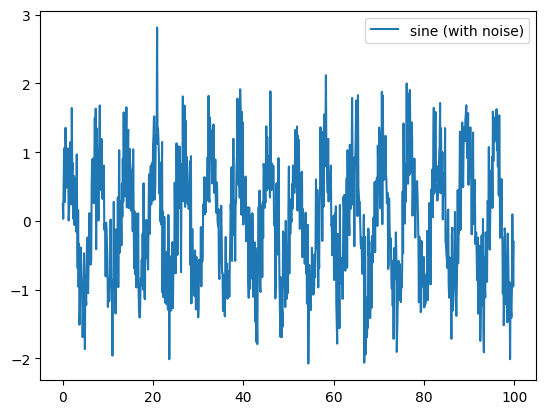

In [ ]:
# =============================================================================
# PREPARE DATA
# =============================================================================

RANDOM_SEED = 42 # for reproducibility

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Generate data
time = np.arange(0, 100, 0.1)
sin = np.sin(time) + np.random.normal(scale=0.5, size=len(time))

plt.plot(time, sin, label='sine (with noise)');
plt.legend();

### Prepare training dataset

In [ ]:
df = pd.DataFrame(dict(sine=sin), index=time, columns=['sine'])
df.head()


,sine
0.0,0.248357
0.1,0.030701
0.2,0.522514
0.3,1.057035
0.4,0.272342


In [ ]:
# Create training dataset
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size
train, test = df.iloc[0:train_size], df.iloc[train_size:len(df)] # no random split!!!
print(len(train), len(test))

def create_training_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

window_size = 1


X_train, y_train = create_training_dataset(train, train.sine, window_size)
X_test, y_test = create_training_dataset(test, test.sine, window_size)

800 200


## reshape to [samples, window_size, n_features]


In [ ]:
# Let's have a look at the training data
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# Show example data
print(X_train[0])
print(y_train[0])

print(X_train[1])
print(y_train[1])

(799, 1, 1) (799,)
(199, 1, 1) (199,)
[[0.24835708]]
0.030701266061235827
[[0.03070127]]
0.5225135998454075


In [ ]:
# =============================================================================
# BENCHMARK MODEL 1: y_t+1 = x_t
# =============================================================================

# Shift time series by one
y_pred = np.roll(y_test, 1)
y_pred[0] = y_train[len(y_train)-1]
# MSE function
mse = tf.keras.metrics.MeanSquaredError()
print('\nTest MSE:', mse(y_pred, y_test).numpy())


Test MSE: 0.44350538


## Models

In [ ]:
# =============================================================================
# BENCHMARK MODEL 2: Linear regression
# =============================================================================

model = keras.Sequential()
model.add(keras.layers.Dense(1))
model.compile(loss='mean_squared_error', metrics=['mean_squared_error'], optimizer=keras.optimizers.SGD(0.01))

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    verbose=1,
    validation_data = (X_test, y_test),
    shuffle=False
)

model.summary()
model.get_weights()

# Evaluate
test_loss, test_mse = model.evaluate(X_test, y_test, verbose=2, batch_size=None)
print('\nTest MSE:', test_mse)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4653 - mean_squared_error: 0.4653 - val_loss: 0.5287 - val_mean_squared_error: 0.5287
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4599 - mean_squared_error: 0.4599 - val_loss: 0.5251 - val_mean_squared_error: 0.5251
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4584 - mean_squared_error: 0.4584 - val_loss: 0.5238 - val_mean_squared_error: 0.5238
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4580 - mean_squared_error: 0.4580 - val_loss: 0.5232 - val_mean_squared_error: 0.5232
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4578 - mean_squared_error: 0.4578 - val_loss: 0.5230 - val_mean_squared_error: 0.5230
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4577 - mean_squared_error: 0.4577 - val_loss: 0.5229 - val_mean_squared_error: 0.5229
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4577 - mean_squared_error: 0.4577 - val_loss: 0.5228 - val_mean

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1, 1)           │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

7/7 - 0s - 23ms/step - loss: 1.0646 - mean_squared_error: 1.0646

Test MSE: 1.0645878314971924


In [ ]:
# Change windows size - to use power of LSTM
window_size = 25


X_train, y_train = create_training_dataset(train, train.sine, window_size)
X_test, y_test = create_training_dataset(test, test.sine, window_size)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(775, 25, 1) (775,)
(175, 25, 1) (175,)


In [ ]:
# =============================================================================
# LSTM MODEL
# =============================================================================
# input shape -> [samples, window_size, n_features]

model = keras.Sequential()
model.add(keras.layers.LSTM(16, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(keras.layers.Dense(1))
model.compile(loss='mean_squared_error', metrics=['mean_squared_error'], optimizer=keras.optimizers.Adam(0.001))

# =============================================================================
# TRAIN
# =============================================================================

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.4396 - mean_squared_error: 0.4396 - val_loss: 0.3601 - val_mean_squared_error: 0.3601
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3239 - mean_squared_error: 0.3239 - val_loss: 0.2906 - val_mean_squared_error: 0.2906
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2800 - mean_squared_error: 0.2800 - val_loss: 0.2622 - val_mean_squared_error: 0.2622
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2644 - mean_squared_error: 0.2644 - val_loss: 0.2621 - val_mean_squared_error: 0.2621
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2616 - mean_squared_error: 0.2616 - val_loss: 0.2637 - val_mean_squared_error: 0.2637
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2597 - mean_squared_error: 0.2597 - val_loss: 0.2660 - val_mean_squared_error: 0.2660
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2582 - mean_squared_error: 0.2582 - val_loss: 0.2680 - val_mean

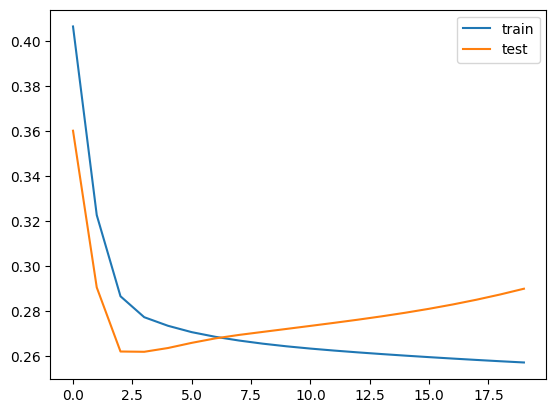

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend();

In [ ]:
# Evaluate
test_loss, test_mse = model.evaluate(X_test, y_test, verbose=2)
print('\nTest MSE:', test_mse)

6/6 - 0s - 9ms/step - loss: 0.2684 - mean_squared_error: 0.2684

Test MSE: 0.26838597655296326


In [ ]:
# Prediction
y_pred = model.predict(X_test, batch_size = 1)

# Show examples
print(y_test[0])
print(y_pred[0])
print(y_test[1])
print(y_pred[1])

175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1.4568760977120174
[0.7003251]
1.584533306882684
[0.7349413]


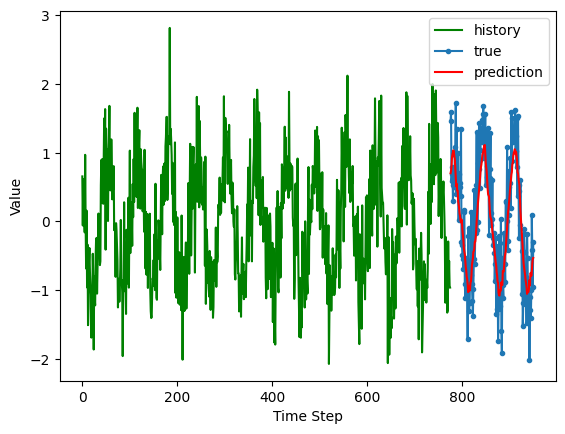

In [ ]:
# Plot prediction and true time series
plt.plot(np.arange(0, len(y_train)), y_train, 'g', label="history")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test, marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), np.squeeze(y_pred), 'r', label="prediction")
plt.ylabel('Value')
plt.xlabel('Time Step')
plt.legend()
plt.show();

# Sequence forecasting

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import os

# Step 1: Generate random time series data
def generate_random_signal(length=1000):
    np.random.seed(42)
    signal = np.sin(np.linspace(0, 100, length)) + np.random.normal(0, 0.5, length)
    return signal
signal = generate_random_signal()
print('signal shape', signal.shape, signal.reshape(-1, 1).shape)

signal shape (1000,) (1000, 1)


In [ ]:

# Step 2: Preprocessing data (for sequence prediction)
def create_dataset(data, look_back=10, predict_length=10):
    X, y = [], []
    for i in range(len(data) - look_back - predict_length):
        X.append(data[i:(i + look_back)])
        y.append(data[(i + look_back):(i + look_back + predict_length)])
    return np.array(X), np.array(y)

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

# Create dataset
look_back = 20
predict_length = 10
X, y = create_dataset(signal_scaled, look_back, predict_length)
# Let's have a look at the training data
print(X.shape, y.shape)


(970, 20) (970, 10)


In [ ]:
# Reshape data to [samples, time steps, features] for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Step 3: Split the data into training and test sets
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Step 4: Build the neural network
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, 1)))
# model.add(Dense(1))
model.add(Dense(predict_length))
model.compile(loss='mean_squared_error', optimizer='adam')

# Step 5: Train the model on the first part of the data
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=2)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 - 1s - 43ms/step - loss: 0.0783
Epoch 2/10
25/25 - 0s - 6ms/step - loss: 0.0294
Epoch 3/10
25/25 - 0s - 6ms/step - loss: 0.0257
Epoch 4/10
25/25 - 0s - 6ms/step - loss: 0.0231
Epoch 5/10
25/25 - 0s - 6ms/step - loss: 0.0192
Epoch 6/10
25/25 - 0s - 6ms/step - loss: 0.0146
Epoch 7/10
25/25 - 0s - 6ms/step - loss: 0.0131
Epoch 8/10
25/25 - 0s - 6ms/step - loss: 0.0123
Epoch 9/10
25/25 - 0s - 6ms/step - loss: 0.0121
Epoch 10/10
25/25 - 0s - 6ms/step - loss: 0.0119


In [ ]:

# Step 8: Make predictions
train_predict = model.predict(X_train)
# test_predict = model.predict(X_test[:1,:]) # prediction for one sample of input
test_predict = model.predict(X_test)

test_predict_mean = test_predict.mean(axis=1)



25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [ ]:
# Let's have a look at the training data
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(776, 20, 1) (776, 10)
(194, 20, 1) (194, 10)


In [ ]:
print(train_predict.shape)
print(test_predict.shape, test_predict_mean.shape)

(776, 10)
(194, 10) (194,)


In [ ]:
# Inverse transform predictions and actual values
train_predict_inv = scaler.inverse_transform(train_predict)

# Reshape y_train and y_test to 2D arrays
y_train_reshaped = y_train.reshape(-1, predict_length)
y_test_reshaped = y_test.reshape(-1, predict_length)

# Inverse transform
y_train_inv = scaler.inverse_transform(y_train_reshaped)
y_test_inv = scaler.inverse_transform(y_test_reshaped)

test_predict_inv = scaler.inverse_transform(test_predict)

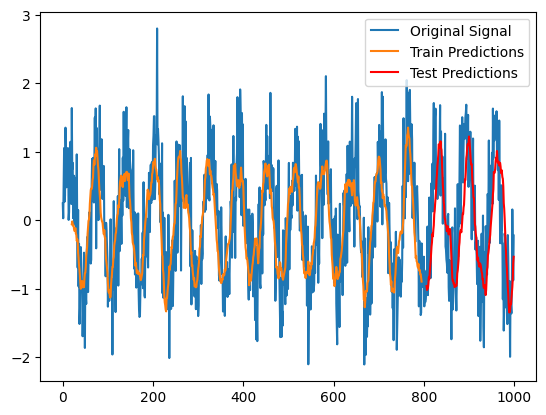

In [ ]:

# Step 9: Plot the predictions vs actual values
plt.plot(signal, label='Original Signal')
plt.plot(np.arange(look_back, len(train_predict) + look_back), train_predict_inv.mean(axis=1), label='Train Predictions')

# Plot predictions on the test set
plt.plot(np.arange(len(train_predict) + (look_back + predict_length), len(signal_scaled)), test_predict_inv.mean(axis=1), label='Test Predictions', color='r')

plt.legend()
plt.show()

# TF for Time series forecasting
https://www.tensorflow.org/tutorials/structured_data/time_series



# LSTM Explained
https://youtu.be/YCzL96nL7j0

# Hyperparameter Tuning


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess the data
X_train = X_train.reshape(-1, 28 * 28).astype('float32') / 255.0  # Flatten the images
X_test = X_test.reshape(-1, 28 * 28).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)  # One-hot encode the labels
y_test = to_categorical(y_test, 10)

# Build the initial simple Feedforward Neural Network
def create_fnn_model(num_layers=2, num_neurons=64):
    model = models.Sequential()
    model.add(layers.Input(shape=(28 * 28,)))  # Input layer

    # Add hidden layers
    for _ in range(num_layers):
        model.add(layers.Dense(num_neurons, activation='relu'))

    # Output layer (10 classes for MNIST)
    model.add(layers.Dense(10, activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Create a model with 2 layers and 64 neurons per layer
model = create_fnn_model(num_layers=2, num_neurons=64)

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=128)

# call function with different parameters

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7912 - loss: 0.7317 - val_accuracy: 0.9411 - val_loss: 0.2000
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9457 - loss: 0.1921 - val_accuracy: 0.9557 - val_loss: 0.1447
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9610 - loss: 0.1370 - val_accuracy: 0.9631 - val_loss: 0.1162
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.1068 - val_accuracy: 0.9670 - val_loss: 0.1011
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0878 - val_accuracy: 0.9687 - val_loss: 0.0938
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9790 - loss: 0.0744 - val_accuracy: 0.9713 - val_loss: 0.0898
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9818 - loss: 0.0638 - val_accuracy: 0.9724 - val_loss: 0.0880
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step -

## Use Keras Tuner

In [ ]:
!pip install keras-tuner


In [ ]:
import keras_tuner as kt

# Define the model-building function for KerasTuner
def build_model(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(28 * 28,)))

    # Tune the number of layers (2-4)
    for i in range(hp.Int('num_layers', 2, 4)):
        # Tune the number of neurons in each layer (32-256)
        model.add(layers.Dense(units=hp.Int('units_' + str(i), min_value=32, max_value=256, step=32),
                               activation='relu'))

    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

# Instantiate the tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='fnn_tuning'
)

# Perform the search
tuner.search(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best number of layers: {best_hps.get('num_layers')}")
for i in range(best_hps.get('num_layers')):
    print(f"Best number of units in layer {i}: {best_hps.get('units_' + str(i))}")


Trial 30 Complete [00h 01m 00s]
val_accuracy: 0.9793999791145325

Best val_accuracy So Far: 0.9794999957084656
Total elapsed time: 00h 13m 36s
Best number of layers: 4
Best number of units in layer 0: 256
Best number of units in layer 1: 256
Best number of units in layer 2: 224
Best number of units in layer 3: 64


In [ ]:
# Get the best model
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
history = best_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 224)            │        57,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339,370 (1.29 MB)

 Trainable params: 339,370 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8866 - loss: 0.3677 - val_accuracy: 0.9620 - val_loss: 0.1256
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9683 - loss: 0.1046 - val_accuracy: 0.9717 - val_loss: 0.0937
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0688 - val_accuracy: 0.9759 - val_loss: 0.0897
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9824 - loss: 0.0561 - val_accuracy: 0.9740 - val_loss: 0.1040
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0444 - val_accuracy: 0.9746 - val_loss: 0.0973
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9889 - loss: 0.0376 - val_accuracy: 0.9779 - val_loss: 0.0878
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9906 - loss: 0.0300 - val_accuracy: 0.9799 - val_loss: 0.0814
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9917 - loss: 0.0278 - 

# More complex example

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt

# Load MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess the data
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0  # Add a channel dimension for CNNs
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)  # One-hot encode the labels
y_test = to_categorical(y_test, 10)

# Build the model
def build_model(hp):
    model = models.Sequential()

    # Convolutional Layers (Tunable number of CNN layers and filters)
    for i in range(hp.Int('num_conv_layers', 1, 2)):
        model.add(layers.Conv2D(
            filters=hp.Int(f'filters_{i}', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice(f'kernel_size_{i}', values=[3, 5]),
            activation=hp.Choice('conv_activation', values=['relu', 'tanh']),
            input_shape=(28, 28, 1) if i == 0 else None  # Input shape for the first layer
        ))
        model.add(layers.MaxPooling2D(pool_size=2))
        model.add(layers.BatchNormalization())

    model.add(layers.Flatten())

    # Dense Layers (Tunable number of Dense layers and neurons)
    for i in range(hp.Int('num_dense_layers', 1, 2)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=64, max_value=256, step=64),
            activation=hp.Choice('dense_activation', values=['relu', 'tanh'])
        ))
        model.add(layers.Dropout(rate=hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)))

    # Output layer (10 classes for MNIST)
    model.add(layers.Dense(10, activation='softmax'))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Instantiate the tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    #This means that after each round, only one-third of the
    #models will continue, and the resource allocation (epochs) will be multiplied by 3 for the next round.
    directory='hyperparam_tuning',
    project_name='mnist_hyperparam_tuning'
)

# Run the hyperparameter search
tuner.search(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best hyperparameters
print(f"Best number of convolutional layers: {best_hps.get('num_conv_layers')}")
for i in range(best_hps.get('num_conv_layers')):
    print(f"Best number of filters in conv layer {i}: {best_hps.get(f'filters_{i}')}")
    print(f"Best kernel size in conv layer {i}: {best_hps.get(f'kernel_size_{i}')}")

print(f"Best number of dense layers: {best_hps.get('num_dense_layers')}")
for i in range(best_hps.get('num_dense_layers')):
    print(f"Best number of units in dense layer {i}: {best_hps.get(f'units_{i}')}")

print(f"Best learning rate: {best_hps.get('learning_rate')}")
print(f"Best dropout rate: {best_hps.get('dropout_rate')}")
print(f"Best activation function for convolutional layers: {best_hps.get('conv_activation')}")
print(f"Best activation function for dense layers: {best_hps.get('dense_activation')}")

# Build the best model and train it
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
history = best_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

# Evaluate the best model
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")


Trial 30 Complete [00h 01m 29s]
val_accuracy: 0.9926999807357788

Best val_accuracy So Far: 0.9934999942779541
Total elapsed time: 00h 18m 43s
Best number of convolutional layers: 2
Best number of filters in conv layer 0: 64
Best kernel size in conv layer 0: 5
Best number of filters in conv layer 1: 64
Best kernel size in conv layer 1: 3
Best number of dense layers: 1
Best number of units in dense layer 0: 256
Best learning rate: 0.0003087530450909568
Best dropout rate: 0.30000000000000004
Best activation function for convolutional layers: relu
Best activation function for dense layers: relu
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9290 - loss: 0.2250 - val_accuracy: 0.9863 - val_loss: 0.0432
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9862 - loss: 0.0461 - val_accuracy: 0.9863 - val_loss: 0.0398
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9898 - loss: 0.0314 - val_accuracy: 0.9891 - val_loss: 0.0351
Epoch 4/10

## Grid Search or Random Search
If you don’t want to use KerasTuner but still want to automate hyperparameter tuning, you can implement grid search or random search using a loop.
Manually define ranges for each hyperparameter and iterate over all possible combinations (grid search) or random combinations (random search).
Example (Random Search Pseudocode):

In [ ]:
'''
import random
def random_search():
    best_val_acc = 0
    for _ in range(10):  # Try 10 random architectures
        num_layers = random.choice([1, 2, 3])
        units_per_layer = random.choice([64, 128, 256])
        activation = random.choice(['relu', 'tanh'])
        learning_rate = random.choice([0.0001, 0.001, 0.01])
        batch_size = random.choice([32, 64, 128])

        # Build the model
        model = tf.keras.Sequential()
        for _ in range(num_layers):
            model.add(layers.Dense(units_per_layer, activation=activation))
        model.add(layers.Dense(output_dim, activation='softmax'))

        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='categorical_crossentropy', metrics=['accuracy'])

        # Train the model
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                            epochs=10, batch_size=batch_size)

        # Check validation accuracy
        val_acc = history.history['val_accuracy'][-1]
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model

    return best_model, best_val_acc

best_model, best_val_acc = random_search()
print(f"Best validation accuracy: {best_val_acc}")
'''

'\nimport random\ndef random_search():\n    best_val_acc = 0\n    for _ in range(10):  # Try 10 random architectures\n        num_layers = random.choice([1, 2, 3])\n        units_per_layer = random.choice([64, 128, 256])\n        activation = random.choice([\'relu\', \'tanh\'])\n        learning_rate = random.choice([0.0001, 0.001, 0.01])\n        batch_size = random.choice([32, 64, 128])\n\n        # Build the model\n        model = tf.keras.Sequential()\n        for _ in range(num_layers):\n            model.add(layers.Dense(units_per_layer, activation=activation))\n        model.add(layers.Dense(output_dim, activation=\'softmax\'))\n\n        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),\n                      loss=\'categorical_crossentropy\', metrics=[\'accuracy\'])\n\n        # Train the model\n        history = model.fit(X_train, y_train, validation_data=(X_val, y_val),\n                            epochs=10, batch_size=batch_size)\n\n        # C

# Step-by-Step Transfer Learning Example with CIFAR-10


In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load the CIFAR-10 dataset
# CIFAR-10 dataset has 60,000 32x32 color images in 10 classes, with 6,000 images per class
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step


In [ ]:
print(X_train.shape)

(12000, 96, 96, 3)


In [ ]:
# prepare data to have min 96x96x3
# use 3 classes of 60000 images, due to RAM capacity in Collab
filter_train = np.isin(y_train, [0, 1, 2])
filter_test = np.isin(y_test, [0, 1, 2])

X_train = X_train[filter_train.flatten()]
y_train = y_train[filter_train]
X_test = X_test[filter_test.flatten()]
y_test = y_test[filter_test]

In [ ]:
# because of MobilNetV2 properties, we need a certain input size
X_train = np.array([tf.image.resize(image, (96, 96)) for image in X_train])
X_test = np.array([tf.image.resize(image, (96, 96)) for image in X_test])


In [ ]:
# remove variables
del filter_train
del filter_test

In [ ]:
# Normalize the data to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


In [ ]:
# One-hot encode the labels (convert class labels into a binary matrix)
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

# Split the training data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [ ]:
print(X_test[0][4])

[[0.6        0.60784316 0.6156863 ]
 [0.6        0.60784316 0.6156863 ]
 [0.61307186 0.6392157  0.6771242 ]
 [0.6261438  0.67058825 0.7385621 ]
 [0.6392157  0.7019608  0.8       ]
 [0.6496732  0.70849675 0.8143791 ]
 [0.6601307  0.71503264 0.8287581 ]
 [0.67058825 0.72156864 0.84313726]
 [0.6915033  0.7359477  0.85882354]
 [0.7124183  0.75032675 0.8745098 ]
 [0.73333335 0.7647059  0.8901961 ]
 [0.7228758  0.7581699  0.8862745 ]
 [0.71241826 0.751634   0.88235295]
 [0.7019608  0.74509805 0.8784314 ]
 [0.67058825 0.7084967  0.8339869 ]
 [0.6392157  0.6718954  0.78954244]
 [0.60784316 0.63529414 0.74509805]
 [0.606536   0.6313726  0.7307189 ]
 [0.6052287  0.627451   0.7163398 ]
 [0.6039216  0.62352943 0.7019608 ]
 [0.61045754 0.6300654  0.7019608 ]
 [0.6169934  0.63660127 0.7019608 ]
 [0.62352943 0.6431373  0.7019608 ]
 [0.62352943 0.6418301  0.7019608 ]
 [0.62352943 0.64052284 0.7019608 ]
 [0.62352943 0.6392157  0.7019608 ]
 [0.6313726  0.6418301  0.7124183 ]
 [0.6392157  0.6444444  0.72

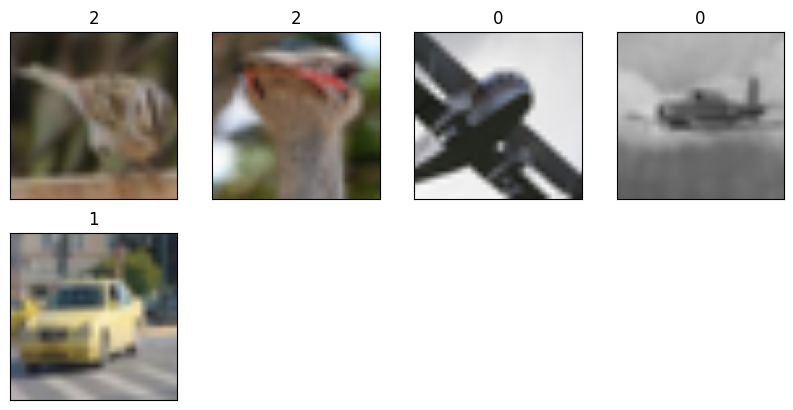

In [ ]:

# Display some images from the dataset
plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(4, 4, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.title(np.argmax(y_train[i]))
plt.show()


In [ ]:

# Step 2: Load a Pretrained Model (MobileNetV2) with Transfer Learning
# MobileNetV2 is a small, efficient model for image classification, pre-trained on ImageNet

# Load the MobileNetV2 model, excluding the top (final) layers, and set input shape to match CIFAR-10

pretrained_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')

# Step 2: Freeze the base model layers to keep the pre-trained weights
for layer in pretrained_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Step 3: Build the Transfer Learning Model
model = models.Sequential()

# Add the pre-trained model as the base
model.add(pretrained_model)

# Add a Global Average Pooling layer to reduce the output of MobileNetV2 to a single vector per image
model.add(layers.GlobalAveragePooling2D())
# Add a fully connected layer with 128 units and ReLU activation
model.add(layers.Dense(128, activation='relu'))

# Add the output layer with 10 units (for 10 classes) and softmax activation for classification
model.add(layers.Dense(3, activation='softmax'))

# Step 4: Compile the Model
# We use Adam optimizer and categorical crossentropy as the loss function, since this is a multi-class classification problem
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


375/375 ━━━━━━━━━━━━━━━━━━━━ 63s 118ms/step - accuracy: 0.8624 - loss: 0.3492 - val_accuracy: 0.9363 - val_loss: 0.1603
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.9185 - loss: 0.2141 - val_accuracy: 0.9347 - val_loss: 0.1639
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.9252 - loss: 0.2024 - val_accuracy: 0.9423 - val_loss: 0.1490
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.9351 - loss: 0.1719 - val_accuracy: 0.9460 - val_loss: 0.1411
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 81ms/step - accuracy: 0.9335 - loss: 0.1695 - val_accuracy: 0.9397 - val_loss: 0.1637
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 80ms/step - accuracy: 0.9464 - loss: 0.1535 - val_accuracy: 0.9450 - val_loss: 0.1431
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.9457 - loss: 0.1441 - val_accuracy: 0.9540 - val_loss: 0.1269
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.9468 - loss: 0.1432 - val_accura

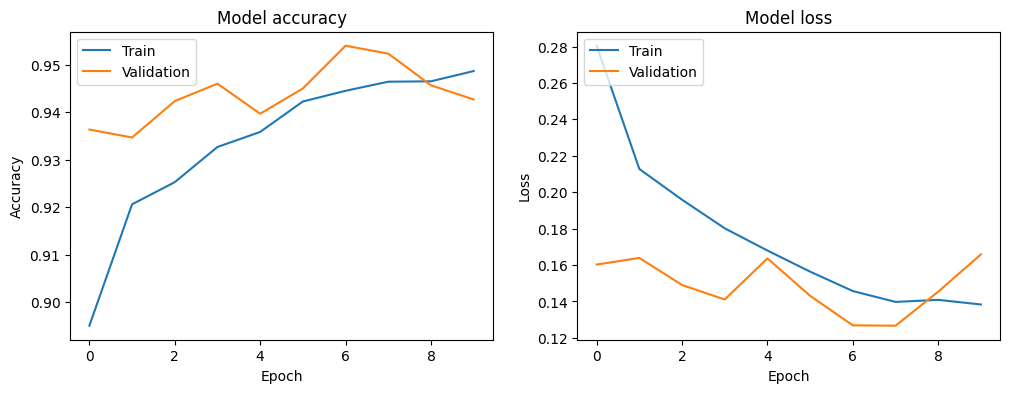

In [ ]:
# Step 5: Perform Data Augmentation
# Data augmentation generates new training samples by randomly transforming existing images, improving model robustness
datagen = ImageDataGenerator(
    rotation_range=20,      # Randomly rotate images by up to 20 degrees
    width_shift_range=0.1,  # Randomly shift the image horizontally by up to 10%
    height_shift_range=0.1, # Randomly shift the image vertically by up to 10%
    horizontal_flip=True,   # Randomly flip images horizontally
)

# Fit the data generator to the training data
datagen.fit(X_train)

# Step 6: Train the Model
# Train the model using the augmented data generator
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),  # Use the data generator for training
    validation_data=(X_val, y_val),
    epochs=10,  # We will train for 10 epochs, but this can be adjusted
    verbose=1
)

# Step 7: Evaluate the Model on Test Data
# After training, evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

# Step 8: Plot Training and Validation Accuracy/Loss
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


## Example Code to Unfreeze Top Layers:
In the example below, let's say we want to unfreeze the last few layers of the pre-trained MobileNetV2 model, while keeping the earlier layers frozen.

  1. Inspect the Pre-trained Model Layers:

In [ ]:
# Print the layer names and indexes in MobileNetV2
for i, layer in enumerate(pretrained_model.layers):
    print(i, layer.name)


0 input_layer_2
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_rel

  2. Unfreeze Specific Layers:
You can unfreeze only a specific number of layers (e.g., the last 20 layers) while keeping the earlier layers frozen:

In [ ]:
# Unfreeze the top 20 layers of MobileNetV2
for layer in pretrained_model.layers[-20:]:
    layer.trainable = True  # Unfreeze the layer so it will be trained

# Freeze the rest of the layers
for layer in pretrained_model.layers[:-20]:
    layer.trainable = False  # Keep the rest frozen


3. Recompile the Model:
Whenever you change the trainable property of any layer, you need to recompile the model to ensure the changes take effect:

In [ ]:
# Recompile the model after changing the trainable layers
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


## Full code example

In [ ]:
# Load the MobileNetV2 model, excluding the top layers
pretrained_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')

# Freeze all layers initially
for layer in pretrained_model.layers:
    layer.trainable = False

# Unfreeze the last 20 layers
for layer in pretrained_model.layers[-20:]:
    layer.trainable = True

# Build the transfer learning model
model = models.Sequential()
model.add(pretrained_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))

# Recompile the model after adjusting trainable layers
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])




# Note to CV
after beeing happy with params and structure, train model again with entire data